In [42]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('birlesik_veri.csv')
df.head()

,id,intersection_id,start_time,end_time,detector_id,camera_id,class_id,direction,total,occupancy_time,speed
0,3736612,354,2022-07-01 00:05:00,2022-07-01 00:10:00,1,1,1,0,65,317,117
1,3736613,354,2022-07-01 00:05:00,2022-07-01 00:10:00,2,1,1,0,76,392,97
2,3736614,354,2022-07-01 00:05:00,2022-07-01 00:10:00,2,1,4,0,6,350,90
3,3736615,354,2022-07-01 00:05:00,2022-07-01 00:10:00,2,1,5,0,6,339,94
4,3736616,354,2022-07-01 00:05:00,2022-07-01 00:10:00,3,1,1,0,39,396,87


SAÇILIM GRAFİĞİ İLE YOĞUNLUK-HIZ

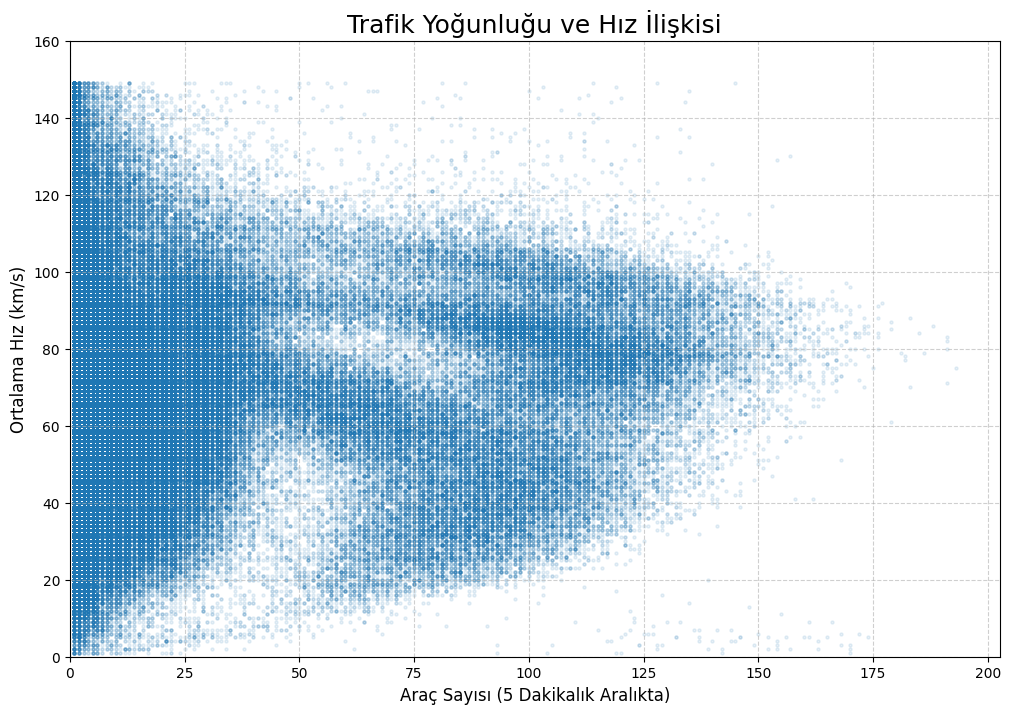

Yoğunluk (total) ve Hız (speed) Arasındaki Korelasyon:
          total     speed
total  1.000000 -0.061251
speed -0.061251  1.000000


In [43]:
plt.figure(figsize=(12, 8), dpi=100) # dpi - çözünürlük ayarı

# çok fazla nokta (250,000+) olduğu için, noktaları şeffaf yaparak yoğun bölgelerin daha belirgin olması sağlanır
plt.scatter(
    df['total'],
    df['speed'],
    alpha=0.1, # Nokta şeffaflığı
    s=5        # Nokta boyutu yine çok fazla veri olduğu için küçültüldü
)

plt.title('Trafik Yoğunluğu ve Hız İlişkisi', fontsize=18)
plt.xlabel('Araç Sayısı (5 Dakikalık Aralıkta)', fontsize=12)
plt.ylabel('Ortalama Hız (km/s)', fontsize=12)
plt.ylim(0, 160) # Y eksenini hız limitine göre ayarla (Maksimum hızımız ~149 idi)
plt.xlim(0)      # X ekseni 0'dan başlasın
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Ek olarak, bu iki değişken arasındaki sayısal ilişkiyi görmek için
# korelasyon katsayısını hesaplayalım. (-1'e ne kadar yakınsa, o kadar güçlü ters ilişki vardır)
korelasyon = df[['total', 'speed']].corr()
print("Yoğunluk (total) ve Hız (speed) Arasındaki Korelasyon:")
print(korelasyon)

negatif 0.06 korelasyon katsayısı (iki değişkeni düz bir çizgiye oturtma işlemi) sıfıra çok yakın olması özellikler arası ilişkinin olmadığı anlamına gelmez doğrusal olmadığı anlamına gelir. yani ilişki yatay bir çizgi içerisinde değil de daha çok L şeklinde hareket eder. sebebi test orantılı olmalarna rağmen ilk başta belli bir duruma kadar birbirini etkilememesidir belli bir durumu geçtikten sonra ilişki asıl şeklini almaya başlar.

Grafikten çıkarılması gereken en önemli sonuç L şeklinin dirsek kısmını bulmaktır. Bu dirsek bize yolun kapasitesini verecektir yani o sınıra gelindiğinde tıkanıklıklar başlamaktadır bize sorunun başını verir. BU grafikte dirsek bölgesi 75-100 arasıdır. O bölgeye kadar hızlarda herhangi bir sıkıntı olmadan yükselirken o aralığı gelince belirgin ölçüde aşağı kaymıştır. Bu şekilde yolun kapasitesini tespit etmede yardımcı olacak parametre bulunmuş olur ve iyileştirme ona göre yapılır.

GRAFİĞİ SAYISAL KANITLAMA (ancak ortalama hızı alacağımızdan gece hız ortalaması yüksek olduğundan sadece 6-21 arası hesaba katılacak)

Gündüz Saatleri (06:00-21:00) Yoğunluk Gruplarına Göre Ortalama Hız:
yogunluk_grubu
(0, 15]       69.9
(15, 30]      63.1
(30, 45]      68.0
(45, 60]      62.1
(60, 75]      54.9
(75, 90]      55.7
(90, 105]     62.8
(105, 120]    70.6
(120, 135]    76.6
(135, 150]    79.4
(150, 165]    78.5
(165, 180]    71.6
(180, 195]    79.4
Name: speed, dtype: float64


/var/folders/mw/y5zpf1vn17bgfjkddgx020p00000gn/T/ipykernel_73090/2546855884.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gunduz['yogunluk_grubu'] = pd.cut(df_gunduz['total'], bins=bin_araliklari)
/var/folders/mw/y5zpf1vn17bgfjkddgx020p00000gn/T/ipykernel_73090/2546855884.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grup_bazli_hiz_gunduz = df_gunduz.groupby('yogunluk_grubu')['speed'].mean()


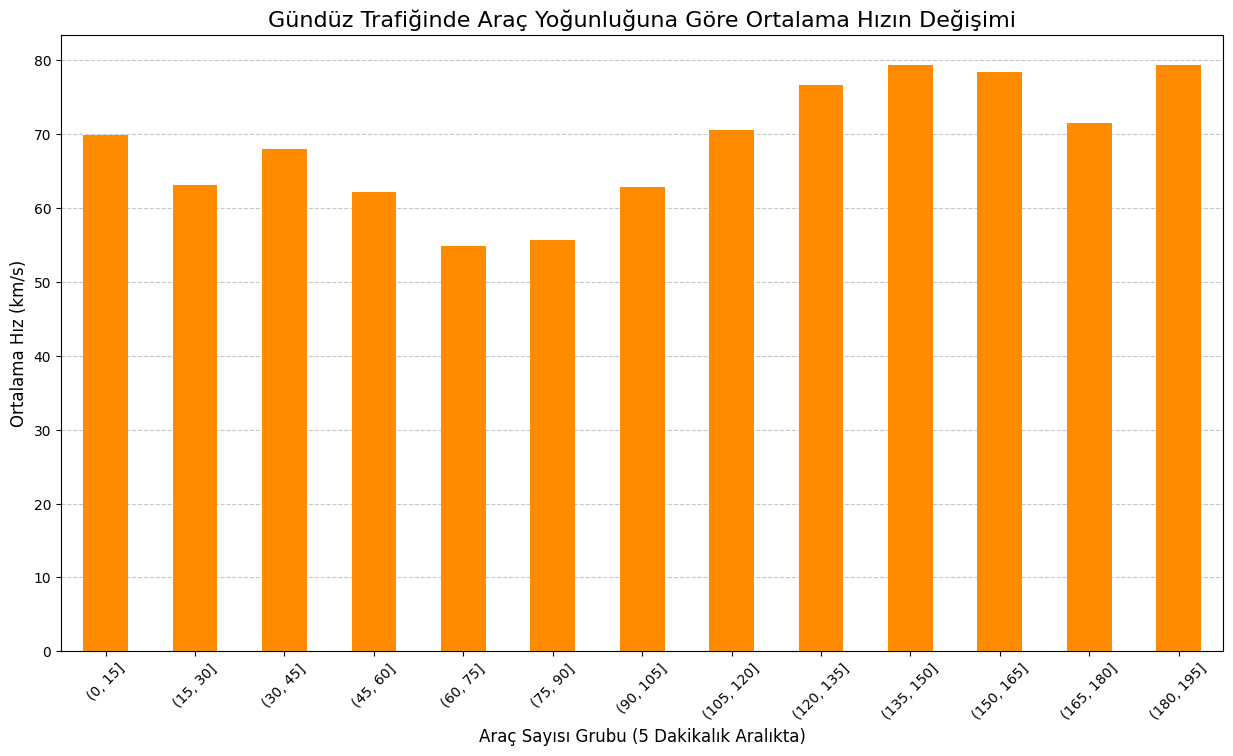

In [44]:
# ÇÖZÜM: Analizden önce bu satırı çalıştırarak sütunu datetime formatına çevirin
df['start_time'] = pd.to_datetime(df['start_time'])


df_gunduz = df[(df['start_time'].dt.hour >= 6) & (df['start_time'].dt.hour < 21)]

bin_araliklari = range(0, 201, 15)
df_gunduz['yogunluk_grubu'] = pd.cut(df_gunduz['total'], bins=bin_araliklari)
grup_bazli_hiz_gunduz = df_gunduz.groupby('yogunluk_grubu')['speed'].mean()

print("Gündüz Saatleri (06:00-21:00) Yoğunluk Gruplarına Göre Ortalama Hız:")
print(grup_bazli_hiz_gunduz.round(1))

plt.figure(figsize=(15, 8))
grup_bazli_hiz_gunduz.plot(kind='bar', color='darkorange', zorder=2)
plt.title('Gündüz Trafiğinde Araç Yoğunluğuna Göre Ortalama Hızın Değişimi', fontsize=16)
plt.xlabel('Araç Sayısı Grubu (5 Dakikalık Aralıkta)', fontsize=12)
plt.ylabel('Ortalama Hız (km/s)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

saçılım grafiğinden çok farklı bir grafik çıktı karşımıza önce yaptığımızda geceyi ayırmamıştık gecenin ortalama hızı yükselttiğini düşündüm ancak sadece gündüzü hesaplattığımda dahi sonuç değişmedi. Bunun sebebi araç sınıfından kaynaklı olabilir. otomobiller daha hızlı seyrettiğinden ve sıkışık saatlerde daha çok otomobilin görülmesi diğer sınıfların ortalama hızlarının hesaplamadaki payını geride bırakacağından karmaşık bir sonuç elde etmiş oluruz. yoğunluk arttıkça büyük araçların trafiği işgal edecek araç sayısı azaltılıyor da olabilir. bunun için sınıfsal inceleme yapmalıyız.

ARAÇ SINIFINA GÖRE PARÇALAMA

Yoğunluk Grupları İçindeki Araç Tipi Dağılımı (%):
class_id                       Otomobil  Ş.arası Otobüs  Hafif Ticari  \
yogunluk_grubu yogunluk_grubu                                           
(0, 15]        (0, 15]             19.5             4.7          41.8   
(15, 30]       (15, 30]            12.9             0.0           6.6   
(30, 45]       (30, 45]            24.0             0.0           0.1   
(45, 60]       (45, 60]            93.5             0.0           0.0   
(60, 75]       (60, 75]            99.9             0.0           0.0   
(75, 90]       (75, 90]           100.0             0.0           0.0   
(90, 105]      (90, 105]          100.0             0.0           0.0   
(105, 120]     (105, 120]         100.0             0.0           0.0   
(120, 135]     (120, 135]         100.0             0.0           0.0   
(135, 150]     (135, 150]         100.0             0.0           0.0   
(150, 165]     (150, 165]         100.0             0.0           0.0   


/var/folders/mw/y5zpf1vn17bgfjkddgx020p00000gn/T/ipykernel_73090/3730765559.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grup_ve_sinif_toplamlari = df_gunduz.groupby(['yogunluk_grubu', 'class_id'])['total'].sum()
/var/folders/mw/y5zpf1vn17bgfjkddgx020p00000gn/T/ipykernel_73090/3730765559.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dagilim_yuzdeleri = grup_ve_sinif_toplamlari.groupby(level=0).apply(lambda x: 100 * x / x.sum()).unstack()


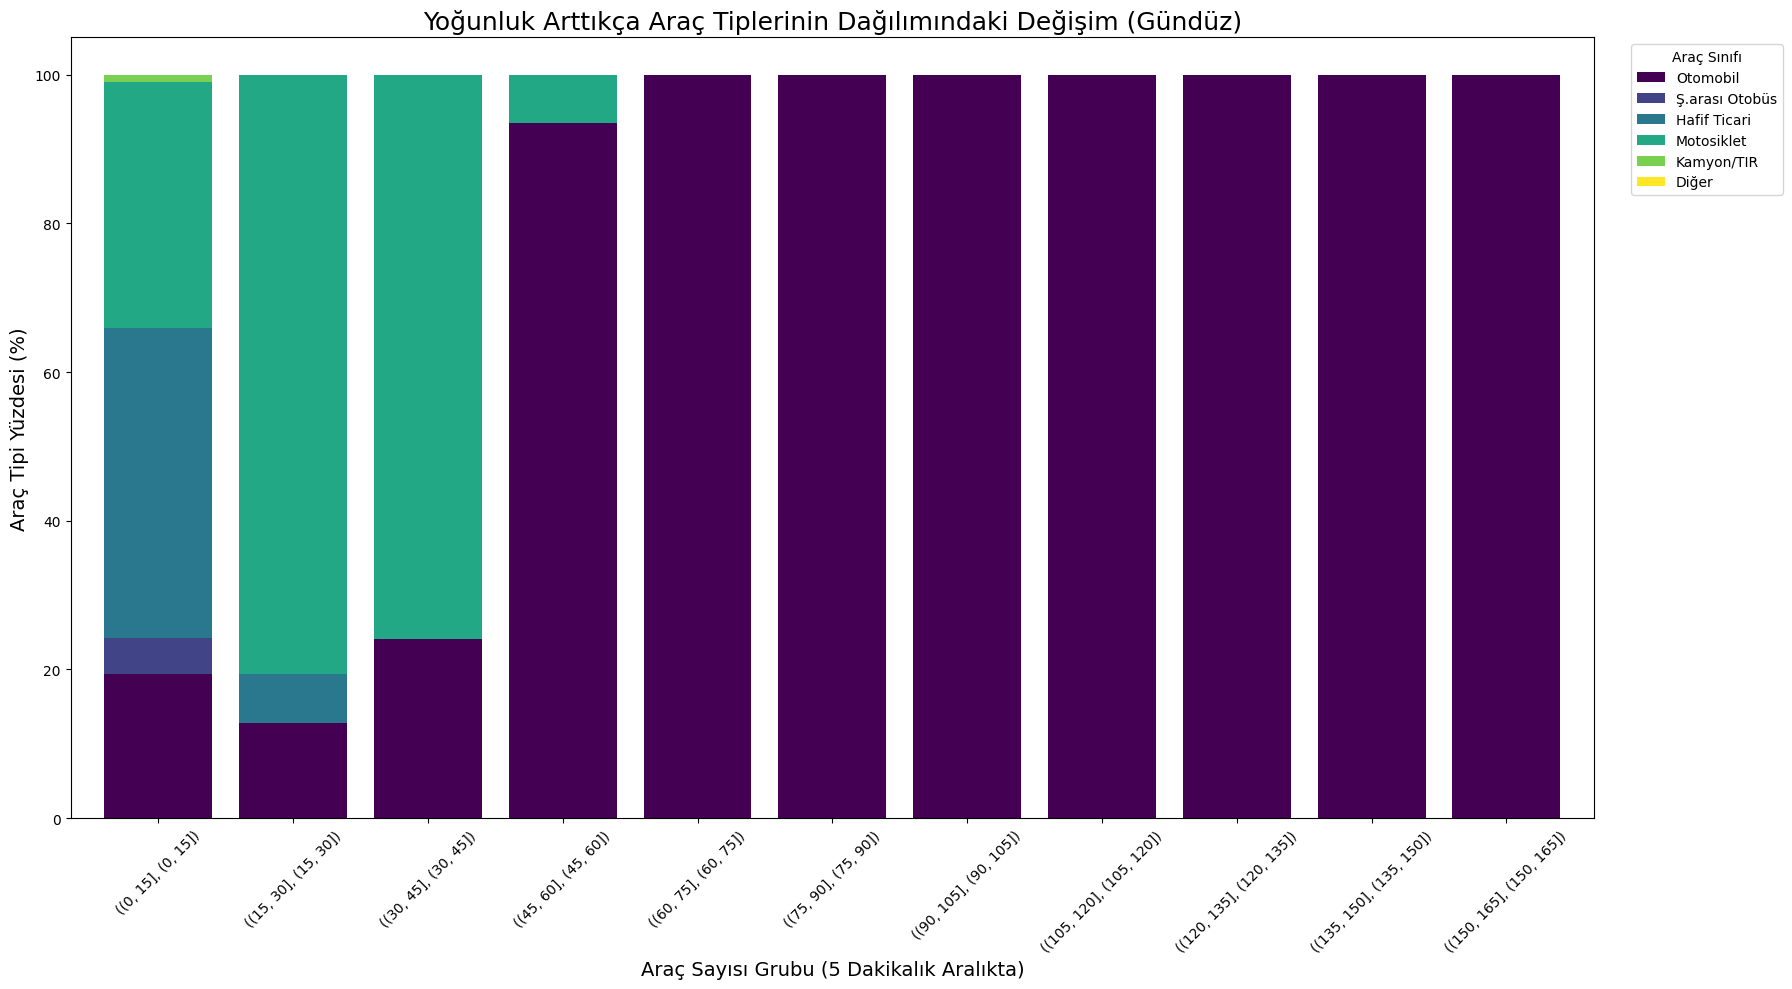

In [45]:
df_gunduz = df[(df['start_time'].dt.hour >= 6) & (df['start_time'].dt.hour < 21)].copy()

# yoğunluk grupları
bin_araliklari = range(0, 166, 15) # 0'dan 165'e kadar 15'erli gruplar
df_gunduz['yogunluk_grubu'] = pd.cut(df_gunduz['total'], bins=bin_araliklari)


# Önce yoğunluk grubuna ve araç sınıfına göre toplam araçları bulalım.
grup_ve_sinif_toplamlari = df_gunduz.groupby(['yogunluk_grubu', 'class_id'])['total'].sum()

# Şimdi her yoğunluk grubu içinde, her sınıfın yüzde kaçını oluşturduğunu hesaplayalım.
# groupby(level=0) -> üstte oluşuturduğumuz sette ilk indeks seviyesine (yogunluk_grubu) göre sırayla gruplama yağacak (0-15 birarada, 15-30 birarada vs.)
# .apply(lambda x: 100 * x / x.sum()) -> her grubun kendi içinde yüzde dağılımını hesaplar (x.sum -> o grubun toplamı, x -> o gruptaki araç sınıfları)
# unstack -> grupları sütunlara dönüştürür
dagilim_yuzdeleri = grup_ve_sinif_toplamlari.groupby(level=0).apply(lambda x: 100 * x / x.sum()).unstack()


# sütunların daha okunaklı olması için önceden bulduğumuz sınıf isimleri
sinif_adlari = {
    1: 'Otomobil',
    3: 'Ş.arası Otobüs',
    4: 'Hafif Ticari',
    5: 'Motosiklet',
    6: 'Kamyon/TIR',
    8: 'Diğer'
}
dagilim_yuzdeleri.columns = dagilim_yuzdeleri.columns.map(sinif_adlari) # sınıf isimleri yerleştirildi


print("Yoğunluk Grupları İçindeki Araç Tipi Dağılımı (%):")
print(dagilim_yuzdeleri.round(1))

# yığılmış sütun grafiğini çizelim
dagilim_yuzdeleri.plot(
    kind='bar',
    stacked=True, # bu parametre grafiği yığılmış hale getirir
    figsize=(18, 10),
    width=0.8,
    colormap='viridis' 
)

plt.title('Yoğunluk Arttıkça Araç Tiplerinin Dağılımındaki Değişim (Gündüz)', fontsize=18)
plt.xlabel('Araç Sayısı Grubu (5 Dakikalık Aralıkta)', fontsize=14)
plt.ylabel('Araç Tipi Yüzdesi (%)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Araç Sınıfı', bbox_to_anchor=(1.02, 1), loc='upper left') # Lejantı grafik dışına taşı
plt.tight_layout()
plt.show()

tamamdır şimdi herşey daha net oldu. tahmin ettiğimiz gibi yoğunluğun arttığı saatde işgaliye süresi yüksek olan ağır vasıta araçlarında ciddi düşüş var ve bu sayede trafik rahatlığı sağlanmış.

TÜM HIZLARIN DAVRANIŞI (*ortalama değil tüm hızlar)

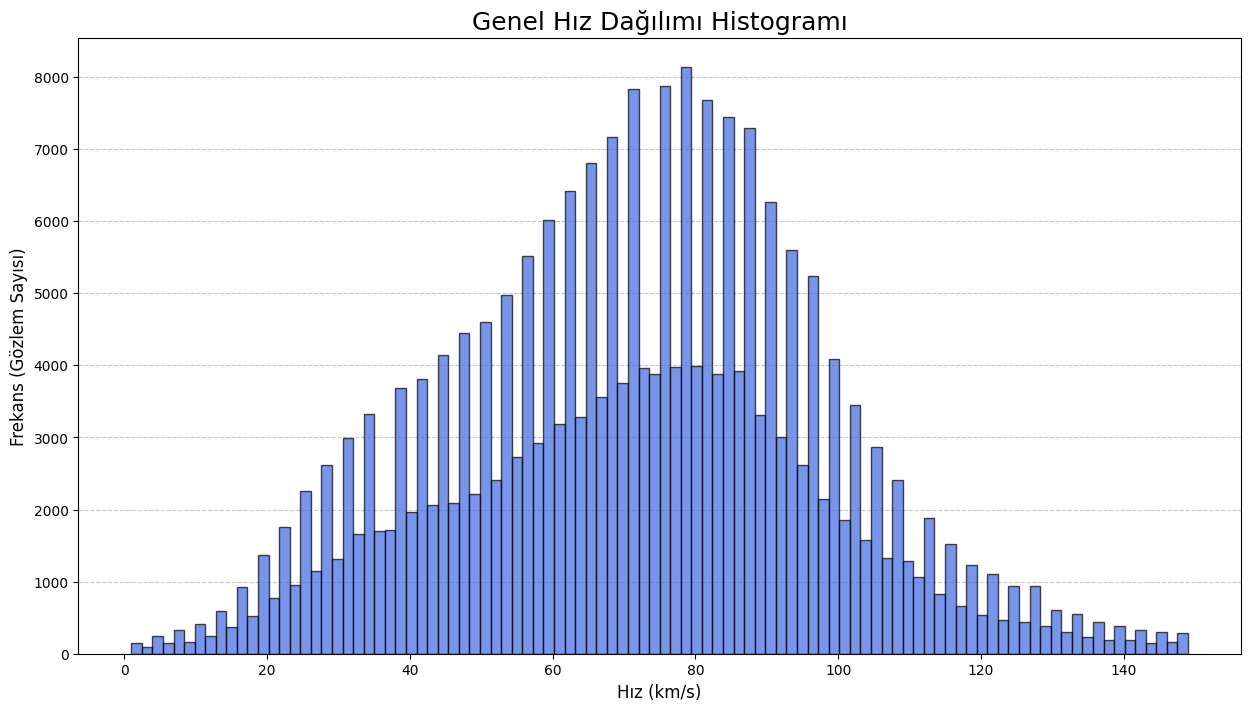

In [46]:
plt.figure(figsize=(15, 8))

# 'bins' parametresi, grafikte kaç tane çubuk olacağını belirler. Daha fazla çubuk, daha detaylı bir dağılım gösterir.
plt.hist(df['speed'], bins=100, color='royalblue', edgecolor='black', alpha=0.7, zorder=2)
plt.title('Genel Hız Dağılımı Histogramı', fontsize=18)
plt.xlabel('Hız (km/s)', fontsize=12)
plt.ylabel('Frekans (Gözlem Sayısı)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Diğer olağan doğal akış durumları gibi grafik çan eğresi şeklindedir. kümelenme genellikle ortada tek tepe noktası yani sistemin olmak istediği durumdur. bu kısım genellikle akıcılığın yüksek olduğu yüksek hızlarda seyretme durumlarıdır ancak kuyruk kısımlarına bakıldığında 0 lara kadar düşen dur-kalk durumları olan trafiğin kopma noktasına geldiği istenmeyen (olmak zorunda kaldığı) durumlarda mevcuttur. bu grafikten çift karakterli bir olay olduğu farklı zaman dilimlerinde farklı haller içerisinde olduğu çıkarımı yapılabilir. (testere dişi şeklinde olmasının sebebi ölçüm sensörlerinin genelde en yakın çift sayıya yuvarlamasından kaynaklıdır)

KORELASYON MATRİSİ (İKİLİ OLARAK DENE)

Korelasyon Matrisi:
                total  speed  occupancy_time  saat  haftanin_gunu
total            1.00  -0.06           -0.00  0.12           0.01
speed           -0.06   1.00           -0.00 -0.09           0.05
occupancy_time  -0.00  -0.00            1.00  0.00          -0.01
saat             0.12  -0.09            0.00  1.00          -0.02
haftanin_gunu    0.01   0.05           -0.01 -0.02           1.00


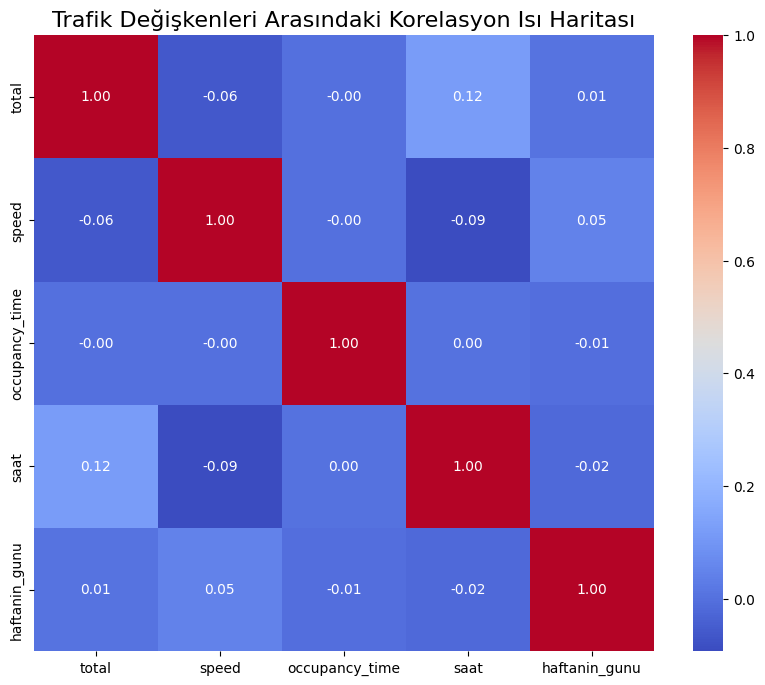

In [47]:
import seaborn as sns

df['saat'] = df['start_time'].dt.hour
df['haftanin_gunu'] = df['start_time'].dt.dayofweek # Pazartesi=0, Pazar=6

# matrisde kulllanacağımız sayısal sütunlar
analiz_df = df[['total', 'speed', 'occupancy_time', 'saat', 'haftanin_gunu']]

korelasyon_matrisi = analiz_df.corr()
print("Korelasyon Matrisi:")
print(korelasyon_matrisi.round(2)) # daha okunaklı olması için yuvarla

# Grafiğin boyutunu ayarlayalım
plt.figure(figsize=(10, 8))

# Seaborn kütüphanesi ile ısı haritasını çizelim
# annot=True -> Değerleri hücrelerin üzerine yazdırır
# cmap='coolwarm' -> Renk paletini belirler (pozitif için sıcak, negatif için soğuk renkler)
sns.heatmap(
    korelasyon_matrisi,
    annot=True,
    cmap='coolwarm',
    fmt=".2f" # Hücrelerdeki sayıların formatı (virgülden sonra 2 basamak)
)

plt.title('Trafik Değişkenleri Arasındaki Korelasyon Isı Haritası', fontsize=16)
plt.show()

matris çok şaşırtıcı sonuçlar verdi. örneğin total sütunu ile işgaliye süresinin pozitif korele yüksek beklerken 0 çıkması çok ilginç. sebebinin belli mantıkları var ancak direkt 0 olması farklı soruları beraberinde getiriyor. Sorunun olmadı doğal senaryo şu şekilde olabilir örneğin arabalar hızlı hızlı geçerken direkt geçiyorlar aşırı düşük işgaliye süresi ancak bir otobüs geldiğinde yavaş yavaş geçitiği için ayrımı arttııyor olabilir gibi mantıklar kurulabilir ancak direkt 0 çıkmasından dolayı imkansız bir ihtimal gibi.

BÜYÜK ARAÇLARIN TRAFİĞE ETKİSİ

Büyük Araçların Otomobil Hızına Etkisi:
buyuk_arac_var_mi
Büyük Araç YOK    88.4
Büyük Araç VAR    70.5
Name: speed, dtype: float64


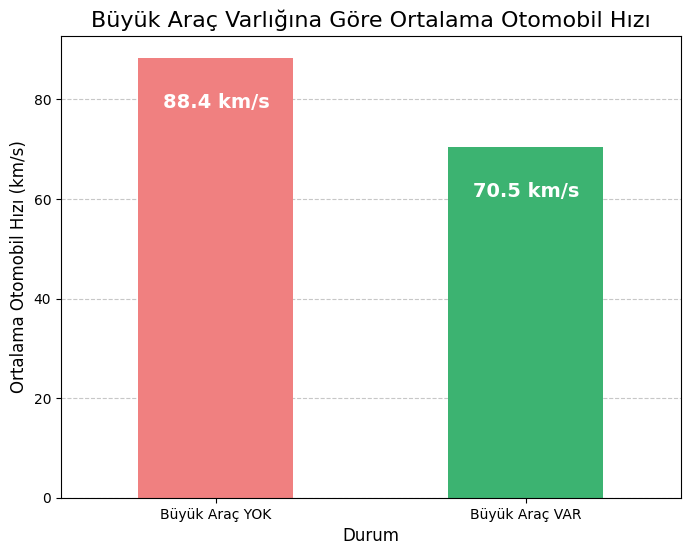

In [48]:
df['start_time'] = pd.to_datetime(df['start_time']) # yine tarih formatına çeviriyoruz
# araç sınıfı isimlerini daha okunaklı hale getirmek için bir sözlük oluşturuyoruz
nihai_sinif_adlari = {
    1: 'Otomobil', 3: 'Ş.arası Otobüs', 4: 'Otobüs', 5: 'Motosiklet', 6: 'Kamyon/TIR', 8: 'Diğer'
}

# yolda o andaki hangi araç sınıflarının olduğunu tespit etme yani yolun fotoğrafını çekme
# Her 5 dakikalık zaman diliminde, her sınıftan kaç araç geçtiğini gösteren bir tablo oluşturuyoruz
# pivot_table kullanarak, 'start_time' sütununu indeks olarak alıyoruz ve 'class_id' sütununu sütun başlığı olarak kullanıyoruz dağınık olan veriyi özetliyoruz
pivot_df = df.pivot_table( 
    index = 'start_time',
    columns = 'class_id',
    values = 'total',
    fill_value = 0 )
# Sütun başlıklarını daha okunaklı olan sınıf isimleriyle değiştiriyoruz.
# map metodu tercüman gibidir ve her sütun başlığını sözlükteki karşılığıyla değiştirir
pivot_df.columns = pivot_df.columns.map(nihai_sinif_adlari)


# tabloda arananlar listesi
buyuk_arac_siniflari = ['Ş.arası Otobüs', 'Otobüs', 'Kamyon/TIR']
pivot_df['buyuk_arac_var_mi'] = pivot_df[buyuk_arac_siniflari].sum(axis=1) > 0 # her 5dk lık pivot satırı için toplam büyük araç sayısını bulur varsa true yoksa false döndürür
# bu lise true, false olarak döner ve tabloya sütun olarak eklenir


# Sadece otomobillere ait hız, zaman bilgilerinin olduğu tablo oluşturulur
df_otomobiller = df[df['class_id'] == 1][['start_time', 'speed']]


# Etiketlediğimiz tablo ile otomobil hızları tablosunu birleştirerek analiz setini oluşturuyoruz.
analiz_df = pd.merge(pivot_df.reset_index(), df_otomobiller, on='start_time')
# bu birleştirmede zaman sütunu baz alınır ve her iki tabloda da bulunan zaman dilimlerine göre eşleştirme yapılır
# hatasız birleştirme için her iki tablodaki zaman dilimlerinin sütun olması gerekir bu yüzden reset_index metodu bunları kenar başlıklarından tekrar sütunlara dönüştürüyoruz
# kenar başlıkları özelliklerden bağımsız birşeydir bu yüzden bu bilgi ile merge çalışmaz birleştirme için özelliklere ait belli bir belirteç olmalı


# "Büyük Araç Var/Yok" etiketine göre gruplayarak ortalama otomobil hızını hesaplıyoruz.
etki_sonucu = analiz_df.groupby('buyuk_arac_var_mi')['speed'].mean()
etki_sonucu.index = etki_sonucu.index.map({True: 'Büyük Araç VAR', False: 'Büyük Araç YOK'})
# Bu indeksleri daha okunaklı hale getiriyoruz (True/False yerine açıklayıcı metinler)
print("Büyük Araçların Otomobil Hızına Etkisi:")
print(etki_sonucu.round(1)) #yuvarla


etki_sonucu.plot(kind='bar', figsize=(8, 6), color=['lightcoral', 'mediumseagreen'], zorder=2)
plt.title('Büyük Araç Varlığına Göre Ortalama Otomobil Hızı', fontsize=16)
plt.xlabel('Durum', fontsize=12)
plt.ylabel('Ortalama Otomobil Hızı (km/s)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for index, value in enumerate(etki_sonucu): # bozuk görüntü, üst üste oluşmamamsı içiçn indexleme
    plt.text(index, value - 10, f'{value:.1f} km/s', ha='center', color='white', fontsize=14, weight='bold')
plt.show()

güzergahta büyük aracın varlığı otomobillerin hızını yaklaşık 18km/s kadar düşürmektedir ve buda neredeyse %20 ile ciddi bir oran. Büyük vasıta araçların trafiğin minimumda olduğu gece saatlerinde yolu kullanmaları yada alternatif farklı yolları güzergaha entegre ederek oradak ulaşımlarını gerçekleştirmeleri sağlanmalıdır.

DEDEKTÖR YER TESPİTİ İÇİN ORTALAMA DEDEKTÖR HIZLARI

Dedektör ID'lerine Göre Ortalama Hızlar (km/s):
detector_id
1    82.6
2    73.9
4    69.6
3    60.9
Name: speed, dtype: float64


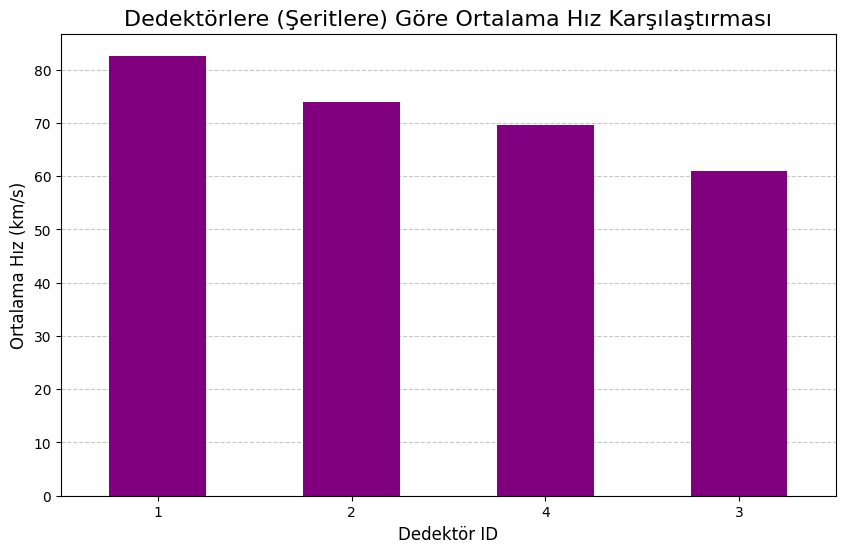

In [49]:
# Her bir 'detector_id'ye göre gruplayarak 'speed' sütununun ortalamasını alınır
ortalama_hiz_per_dedektor = df.groupby('detector_id')['speed'].mean().sort_values(ascending=False)
# yorumlama için sortvalues ile küçükten büyüğü sırala

print("Dedektör ID'lerine Göre Ortalama Hızlar (km/s):")
print(ortalama_hiz_per_dedektor.round(1))

plt.figure(figsize=(10, 6))
ortalama_hiz_per_dedektor.plot(kind='bar', color='purple', zorder=2)
plt.title('Dedektörlere (Şeritlere) Göre Ortalama Hız Karşılaştırması', fontsize=16)
plt.xlabel('Dedektör ID', fontsize=12)
plt.ylabel('Ortalama Hız (km/s)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

dedektörlerin ortalama hızlarına bakıldığında en sol şeritten sağa sıralı olarak sıralanıyor gibi gözükmektedir.

ARAÇ TİPİ DAĞILIMINA GÖRE DEDEKTÖRLER

Dedektörlere Göre Araç Tipi Dağılımı (%):
class_id     Otomobil  Ş.arası Otobüs  Otobüs  Motosiklet  Kamyon/TIR  Diğer
detector_id                                                                 
1                86.3             0.2     1.7        11.8         0.0    0.0
2                82.6             0.3     3.6        13.2         0.1    0.0
3                72.6             0.7     7.0        19.6         0.1    0.0
4                88.8             0.2     1.3         9.2         0.4    0.0


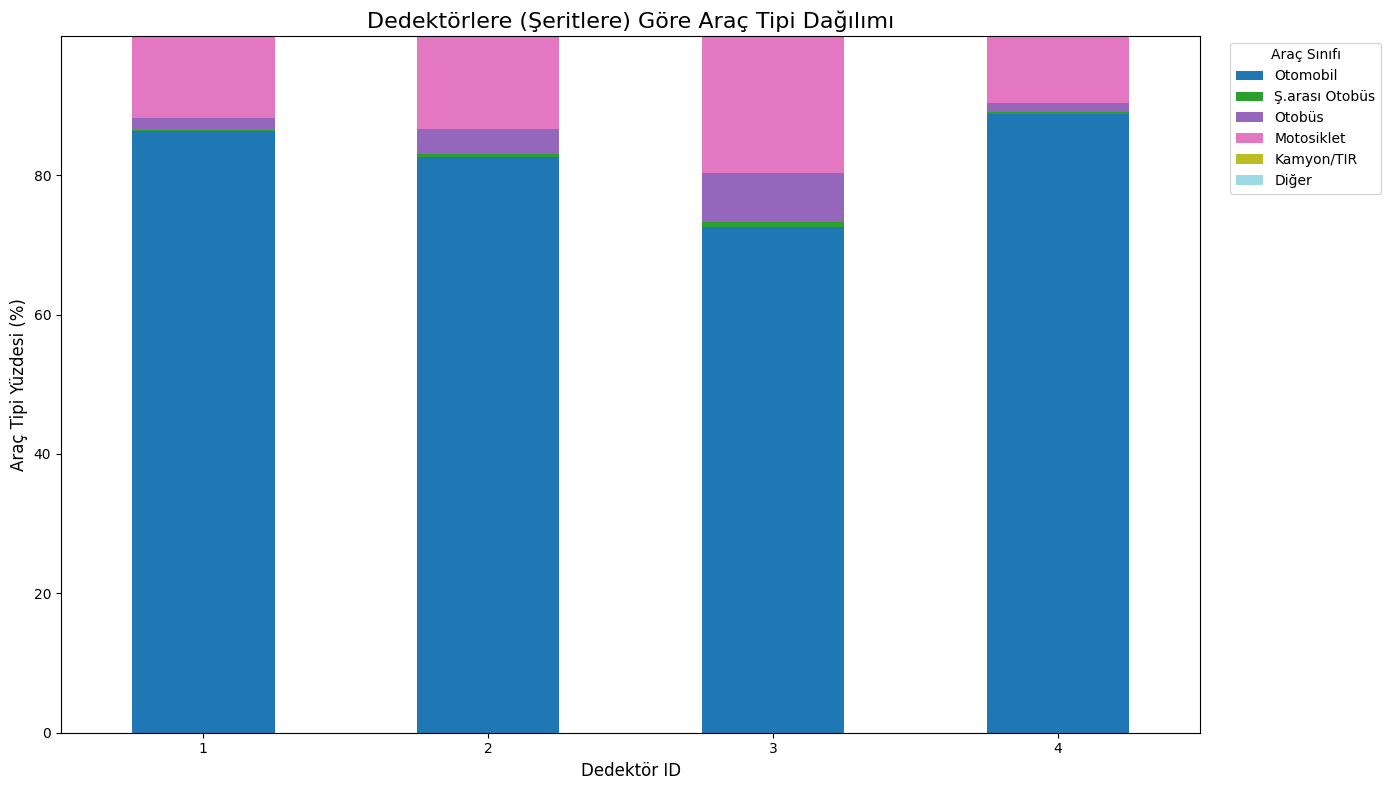

In [50]:
# Her bir dedektör için, her bir araç sınıfının toplam sayısını bulalım
sinif_dagilimi = df.groupby(['detector_id', 'class_id'])['total'].sum().unstack().fillna(0)

# Her dedektördeki toplam araç sayısı
toplam_arac_per_dedektor = sinif_dagilimi.sum(axis=1)
# Her sınıfın, o dedektördeki toplam trafiğin yüzde kaçını oluşturduğunu hesaplayalım
yuzdelik_dagilim = sinif_dagilimi.div(toplam_arac_per_dedektor, axis=0) * 100 # div metodu bölme işlemi yapar

# Sütunları daha okunaklı olması için gerçek sınıf isimlerine dönüştür
yuzdelik_dagilim.columns = yuzdelik_dagilim.columns.map(nihai_sinif_adlari)

print("Dedektörlere Göre Araç Tipi Dağılımı (%):")
print(yuzdelik_dagilim.round(1))
yuzdelik_dagilim.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='tab20' # Daha fazla renk içeren bir palet
)
plt.title('Dedektörlere (Şeritlere) Göre Araç Tipi Dağılımı', fontsize=16)
plt.xlabel('Dedektör ID', fontsize=12)
plt.ylabel('Araç Tipi Yüzdesi (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Araç Sınıfı', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


burada da hız incelemesinde olduğu gibi aynı sonuçları çıkmakdatır. 4. dedektörde otomobil grubunun yüksek çıkmasının sebebi hız kaynaklı olmasından ziyade muhtemelen ilk başta dediğimiz gibi 3 ana şerit + 1 yan ayrım şeridi olduğundan 4. dedektör ayrım şeridi olabilir. bunun tespiti içinde daha tutarlı olması adına toplam araç sayısını karşılaştıracağız

Dedektör ID'lerine Göre Toplam Araç Sayısı:
detector_id
2    2703176
1    2563732
3    1906858
4     211346
Name: total, dtype: int64


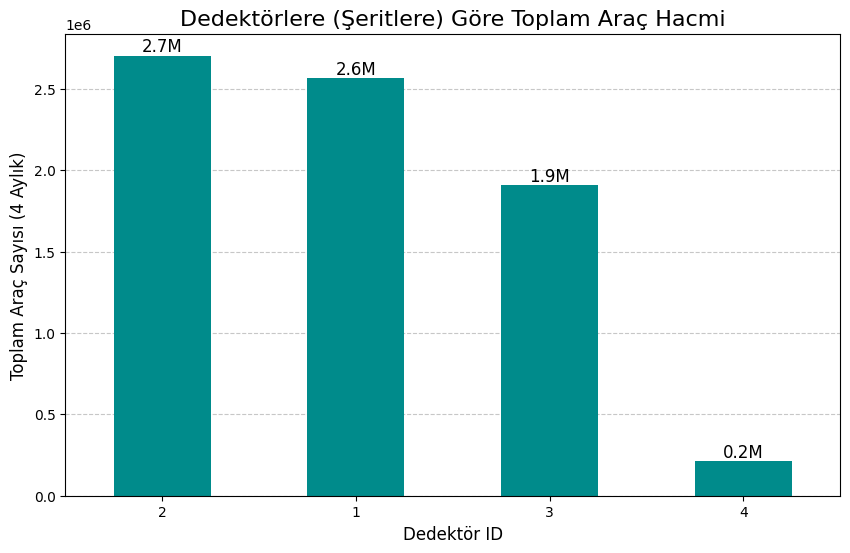

In [51]:
toplam_arac_per_dedektor = df.groupby('detector_id')['total'].sum().sort_values(ascending=False)

print("Dedektör ID'lerine Göre Toplam Araç Sayısı:")
print(toplam_arac_per_dedektor)
plt.figure(figsize=(10, 6))
toplam_arac_per_dedektor.plot(kind='bar', color='darkcyan', zorder=2)
plt.title('Dedektörlere (Şeritlere) Göre Toplam Araç Hacmi', fontsize=16)
plt.xlabel('Dedektör ID', fontsize=12)
plt.ylabel('Toplam Araç Sayısı (4 Aylık)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(toplam_arac_per_dedektor):
    plt.text(index, value, f'{value/1_000_000:.1f}M', ha='center', va='bottom', fontsize=12) # Milyon olarak yaz

plt.show()

bu çıktıda söylediklerimizi doğruluyor. en soldan itibaren şerit sırası dedektör numarası ile sıralı gidiyor ve 4. dedektörden ciddi oranda diğer dedektörlere göre az kullanım, hızın azlığı ve araç kullanım sınıfının farklılığı ile rampa şeridi de 4. dedektörün olduğu şerit oluyor

HAVA DURUMU


--- ANALİZ SONUCU ---
Aylık Haftalara Göre Toplam Yağış Miktarları (mm):
Temmuz - 1. Hafta       0.500000
Temmuz - 2. Hafta     480.100006
Temmuz - 3. Hafta      46.400002
Temmuz - 4. Hafta       0.600000
Temmuz - 5. Hafta      35.400002
Ağustos - 1. Hafta     52.299999
Ağustos - 2. Hafta    132.300003
Ağustos - 3. Hafta    443.799988
Ağustos - 4. Hafta    151.500000
Eylül - 1. Hafta      278.899994
Eylül - 2. Hafta       51.799999
Eylül - 3. Hafta      385.299988
Eylül - 4. Hafta      715.599976
Ekim - 1. Hafta         7.100000
Ekim - 2. Hafta         0.000000
Ekim - 3. Hafta         0.000000
Ekim - 4. Hafta         0.000000
Ekim - 5. Hafta         0.000000
Kasım - 1. Hafta        1.700000
Kasım - 2. Hafta       21.400000
Kasım - 3. Hafta      211.300003
Kasım - 4. Hafta      689.400024
Name: precipitation_mm, dtype: float32


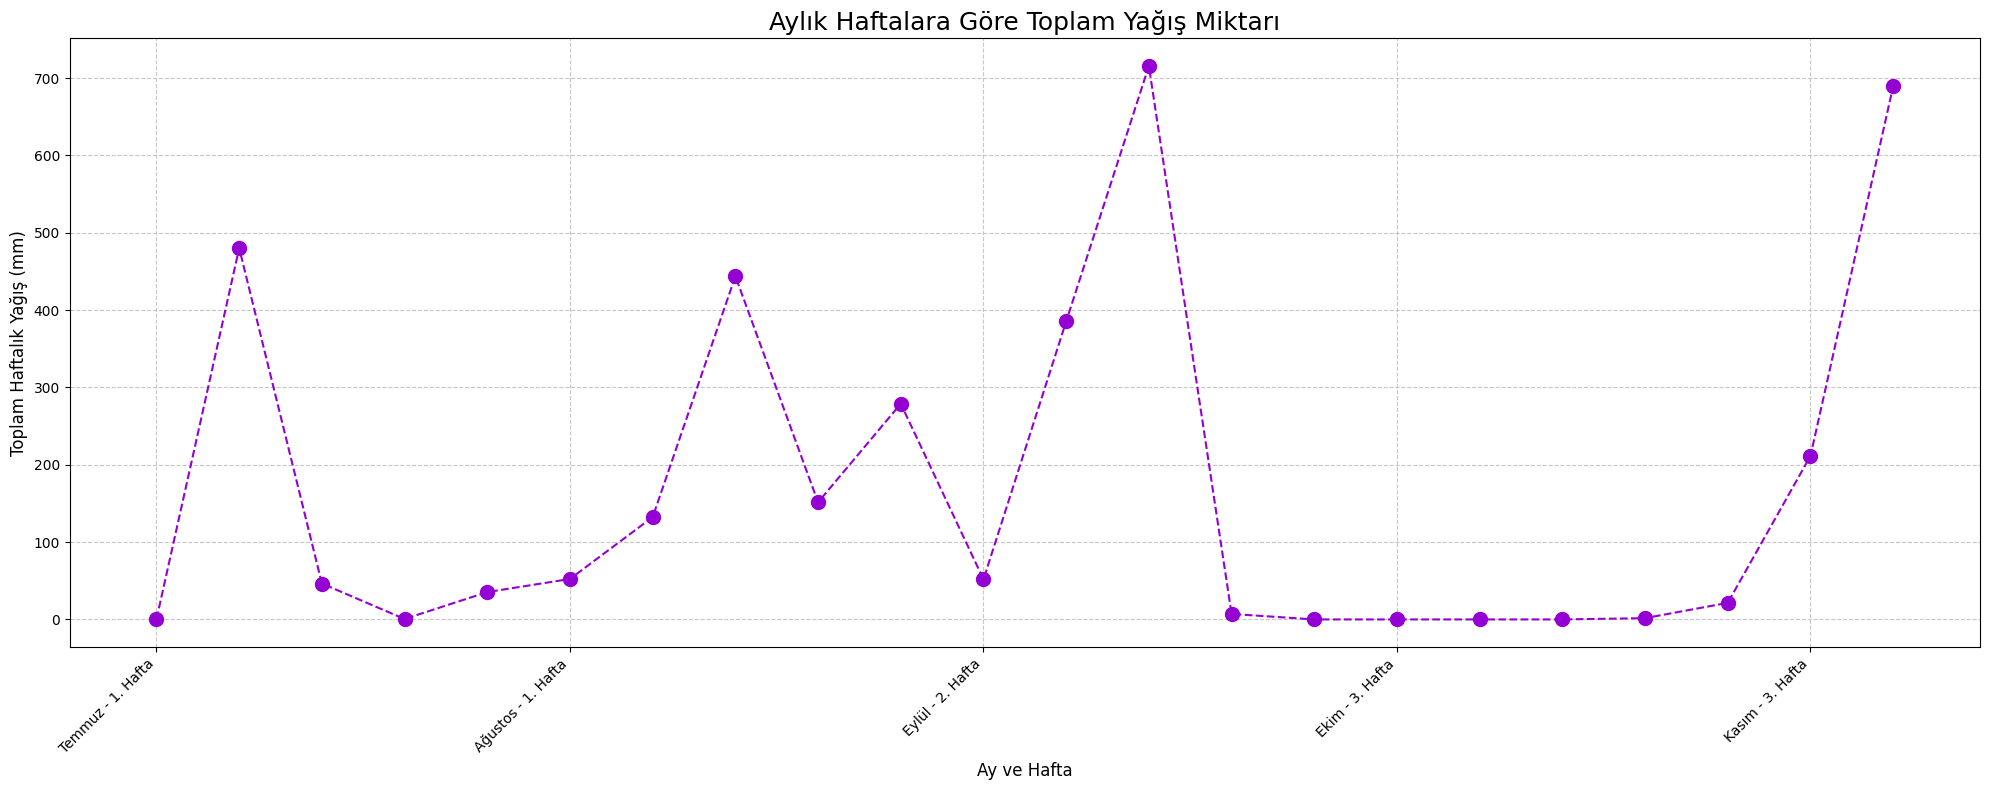

In [52]:

import xarray as xr
import locale

# Türkçe ay isimleri için lokal ayarını yapalım
try:
    locale.setlocale(locale.LC_TIME, 'tr_TR.UTF-8')
except locale.Error:
    print("Türkçe lokal ayarı yapılamadı, ay isimleri İngilizce olabilir.")


# Bu adımlar öncekiyle aynı.
dosya_listesi = ['data_0.nc', 'data_0.nc 2', 'data_0.nc 3', 'data_0.nc 4']
tum_hava_verileri = []
for dosya_adi in dosya_listesi:
    try:
        hava_dataseti = xr.open_dataset(dosya_adi, engine='netcdf4') # NetCDF dosyasını açıyoruz
        df_hava = hava_dataseti.to_dataframe().reset_index() # DataFrame'e çeviriyoruz
        if 'valid_time' in df_hava.columns: # Eğer 'valid_time' sütunu varsa
            df_hava = df_hava.rename(columns={'valid_time': 'saatlik_zaman'}) # sütunu yeniden adlandırıyoruz
        elif 'time' in df_hava.columns: # eğer 'time' sütunu varsa
            df_hava = df_hava.rename(columns={'time': 'saatlik_zaman'})
        tum_hava_verileri.append(df_hava[['saatlik_zaman', 'tp']]) # 'saatlik_zaman' ve 'tp' sütunlarını alıyoruz
    except Exception as e: # herhangi bir hata oluşursa
        print(f"'{dosya_adi}' okunurken bir hata oluştu: {e}")


if tum_hava_verileri:
    birlesik_hava_df = pd.concat(tum_hava_verileri, ignore_index=True) # dosyaları birleştiriyoruz
    
    birlesik_hava_df['precipitation_mm'] = birlesik_hava_df['tp'] * 1000 # 'tp' sütununu mm cinsine çeviriyoruz
    birlesik_hava_df['saatlik_zaman'] = pd.to_datetime(birlesik_hava_df['saatlik_zaman']) # 'saatlik_zaman' sütununu datetime formatına çeviriyoruz
    birlesik_hava_df = birlesik_hava_df.set_index('saatlik_zaman') # 'saatlik_zaman' sütununu indeks olarak ayarlıyoruz
    
    # Veriyi takvim haftalarına göre grupla ve toplam yağışı bul
    haftalik_yagislar = birlesik_hava_df['precipitation_mm'].resample('W').sum()
    
    # Sadece verinin olduğu tarih aralığını al
    son_veri_tarihi = birlesik_hava_df.index.max()
    haftalik_yagislar = haftalik_yagislar[haftalik_yagislar.index <= son_veri_tarihi]
    
    # Her Ayın Haftalarını Ayrı Ayrı Etiketleme ---
    # Her haftanın hangi aya ait olduğunu bul
    haftanin_ayi = haftalik_yagislar.index.strftime('%B') # Ayın tam adını al (örn: Temmuz)
    # Her ayın içinde haftaları 1'den başlayarak numaralandır
    hafta_numarasi = haftalik_yagislar.groupby(haftanin_ayi).cumcount() + 1
    
    # Yeni etiketleri oluşturalım: "Temmuz - 1. Hafta", "Temmuz - 2. Hafta" ...
    yeni_etiketler = [f"{ay} - {hafta}. Hafta" for ay, hafta in zip(haftanin_ayi, hafta_numarasi)]

    # Bu yeni etiketleri veri setimizin indeksi yapalım
    haftalik_yagislar.index = yeni_etiketler

    print("\n--- ANALİZ SONUCU ---")
    print("Aylık Haftalara Göre Toplam Yağış Miktarları (mm):")
    print(haftalik_yagislar.round(1))
    
    # Sonucu bir nokta grafiği (işaretli çizgi grafiği) ile görselleştirelim
    plt.figure(figsize=(20, 8))
    haftalik_yagislar.plot(
        kind='line',
        style='o--', # Noktaları kesikli çizgiyle birleştir
        markersize=10,
        color='darkviolet',
        zorder=2
    )
    plt.title('Aylık Haftalara Göre Toplam Yağış Miktarı', fontsize=18)
    plt.xlabel('Ay ve Hafta', fontsize=12)
    plt.ylabel('Toplam Haftalık Yağış (mm)', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Etiketlerin okunurluğu için
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("\nHiçbir hava durumu dosyası başarıyla okunamadı.") 


ağustos ve eylülde bol yağışlı zamanlar mevcut olduğundan bu iki ay içleride yeterince örnek bulunabileceğinden bu iki ay üzerinden gidelim

AĞUSTOS - EYLÜL GÜNLÜK HAVA DURUMU


--- ANALİZ SONUCU ---
Ağustos ve Eylül Ayları Günlük Toplam Yağış Miktarları (mm):
saatlik_zaman
2022-08-01     6.0
2022-08-02     9.6
2022-08-03    12.2
2022-08-04     1.3
2022-08-05     3.6
              ... 
2022-09-26     0.0
2022-09-27     3.7
2022-09-28     2.2
2022-09-29     1.1
2022-09-30     0.1
Freq: D, Name: precipitation_mm, Length: 61, dtype: float32


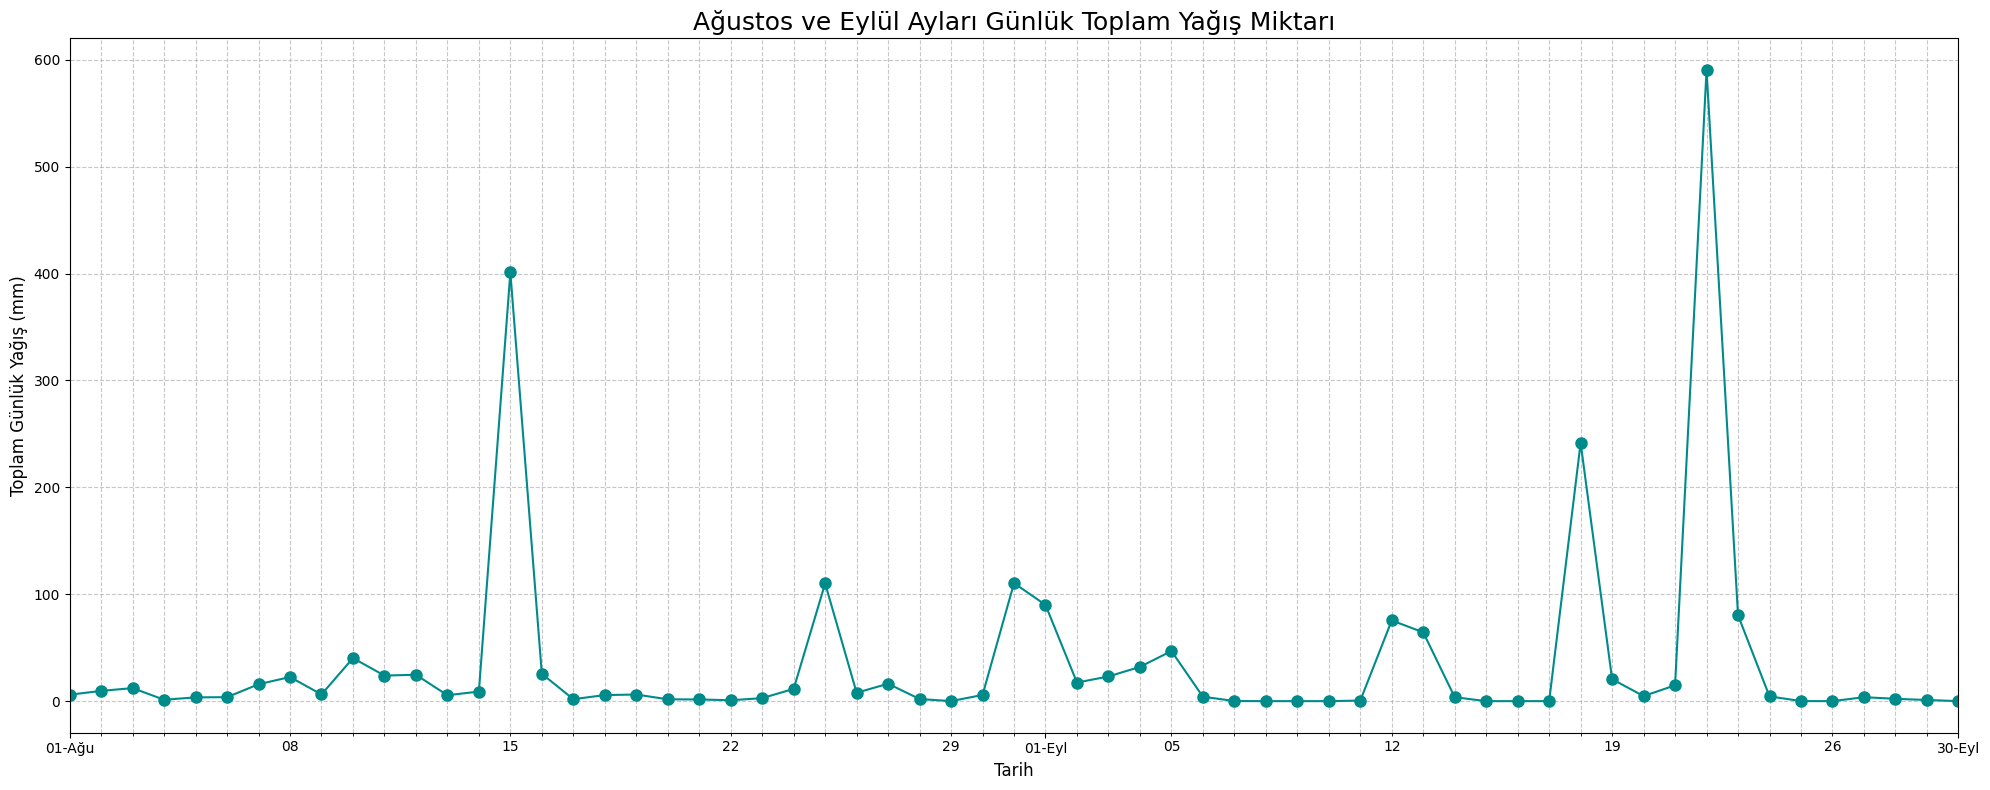

In [59]:
import matplotlib.dates as mdates

# Zaten hafızada olan 'birlesik_hava_df'yi kullanıyoruz.
# resample('D') metodu ile veriyi takvim günlerine göre grupla ve her günün toplam yağışını bul
gunluk_yagislar = birlesik_hava_df['precipitation_mm'].resample('D').sum()

# sadece Ağustos ve Eylül Aylarını Filtreleme ---
agustos_eylul_yagis = gunluk_yagislar[gunluk_yagislar.index.month.isin([8, 9])]


print("\n--- ANALİZ SONUCU ---")
print("Ağustos ve Eylül Ayları Günlük Toplam Yağış Miktarları (mm):")
print(agustos_eylul_yagis.round(1))

# Sonucu bir nokta grafiği (işaretli çizgi grafiği) ile görselleştirelim
fig, ax = plt.subplots(figsize=(20, 8))

agustos_eylul_yagis.plot(
    ax=ax,
    style='o-', # Noktaları düz çizgiyle birleştir
    markersize=8,
    color='darkcyan',
    zorder=2
)

ax.set_title('Ağustos ve Eylül Ayları Günlük Toplam Yağış Miktarı', fontsize=18)
ax.set_xlabel('Tarih', fontsize=12)
ax.set_ylabel('Toplam Günlük Yağış (mm)', fontsize=12)
# X eksenindeki tarih formatını daha okunaklı yapalım (örn: 01-Ağu, 15-Eyl)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
# Arka plana kılavuz çizgileri ekleyelim
ax.grid(True, which='both', linestyle='--', alpha=0.7)
# Grafiğin kenar boşluklarını otomatik ayarla
fig.tight_layout()
plt.show()

inceleme için tam uygun olan set şeklinde. yağışsız günler, az yağışlı ve ciddi yağışlı günler her türden var

YAĞIŞ - İŞGALİYE SÜRESİ KORELASYONU

Trafik verisinden günlük ortalama işgaliye süresi hesaplanıyor...
Günlük yağış ve işgaliye verileri birleştiriliyor...

Analiz sonuçları oluşturuluyor...


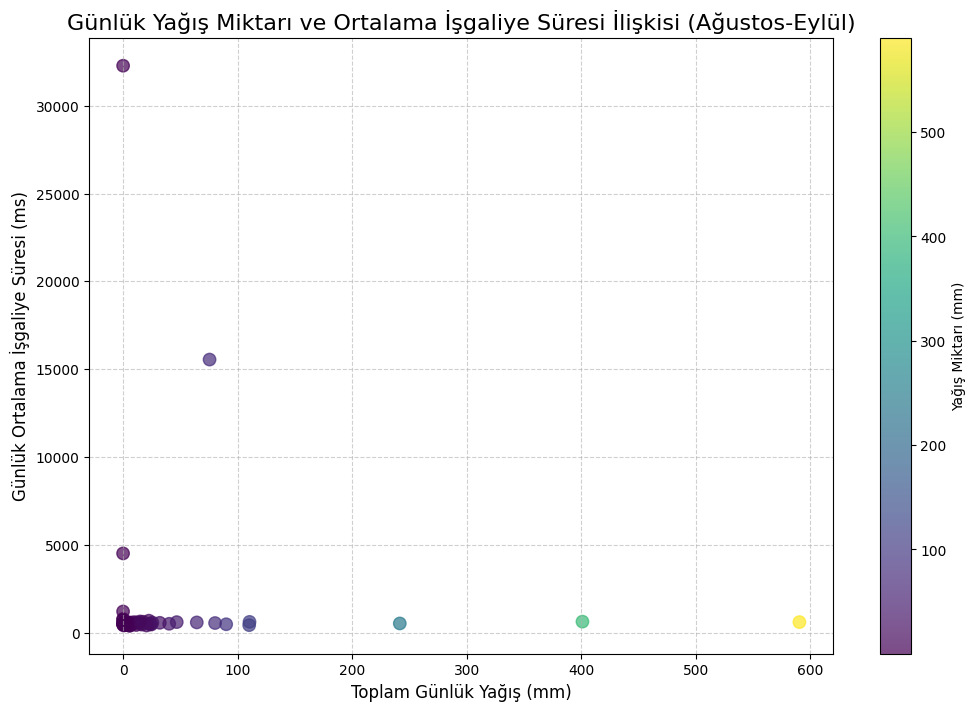


Yağış ve İşgaliye Süresi Arasındaki Korelasyon:
                  precipitation_mm  occupancy_time
precipitation_mm          1.000000       -0.027511
occupancy_time           -0.027511        1.000000


In [54]:
# Trafik Verisinden Günlük Ortalama İşgaliye Süresini Hesaplama ---
# (Bu kısım doğru çalıştığı için aynı kalıyor)
print("Trafik verisinden günlük ortalama işgaliye süresi hesaplanıyor...")
if 'gun' not in df.columns:
    df['gun'] = pd.to_datetime(df['start_time'].dt.date)
gunluk_ortalama_isgaliye = df.groupby('gun')['occupancy_time'].mean()


# İki Veriyi Birleştirme (Düzeltilmiş Kısım) 
print("Günlük yağış ve işgaliye verileri birleştiriliyor...")

# DÜZELTME: Yağış tablosunu daha garantili bir yöntemle hazırlayalım.
# Önce tabloyu oluşturalım.
yagis_df = gunluk_yagislar.reset_index()
# Şimdi sütun adlarını doğrudan biz belirleyelim. Bu, her zaman doğru çalışır.
yagis_df.columns = ['gun', 'precipitation_mm']

# İki tabloyu birleştirelim.
karsilastirma_df = pd.merge(
    yagis_df,
    gunluk_ortalama_isgaliye.reset_index(),
    on='gun'
)
# Sadece Ağustos ve Eylül aylarını filtreleyelim.
karsilastirma_df = karsilastirma_df[karsilastirma_df['gun'].dt.month.isin([8, 9])]


print("\nAnaliz sonuçları oluşturuluyor...")
plt.figure(figsize=(12, 8))
plt.scatter(
    karsilastirma_df['precipitation_mm'],
    karsilastirma_df['occupancy_time'],
    alpha=0.7, s=80, c=karsilastirma_df['precipitation_mm'], cmap='viridis'
)
plt.title('Günlük Yağış Miktarı ve Ortalama İşgaliye Süresi İlişkisi (Ağustos-Eylül)', fontsize=16)
plt.xlabel('Toplam Günlük Yağış (mm)', fontsize=12)
plt.ylabel('Günlük Ortalama İşgaliye Süresi (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.colorbar(label='Yağış Miktarı (mm)')
plt.show()

korelasyon = karsilastirma_df[['precipitation_mm', 'occupancy_time']].corr()
print("\nYağış ve İşgaliye Süresi Arasındaki Korelasyon:")
print(korelasyon)

DEDEKTÖR DOĞRULUĞU BULMAK İÇİN İSGALİYE SÜRESİ İLE TOPLAM ARAÇ KORELASYONLARI

Her dedektör için tutarlılık analizi yapılıyor...
- Dedektör 1 için korelasyon hesaplandı: -0.005
- Dedektör 2 için korelasyon hesaplandı: -0.003
- Dedektör 3 için korelasyon hesaplandı: -0.003
- Dedektör 4 için korelasyon hesaplandı: 0.056

--- ANALİZ SONUCU ---
Dedektörlerin Tutarlılık (Korelasyon) Puanları:
Dedektör 4    0.056
Dedektör 3   -0.003
Dedektör 2   -0.003
Dedektör 1   -0.005
dtype: float64


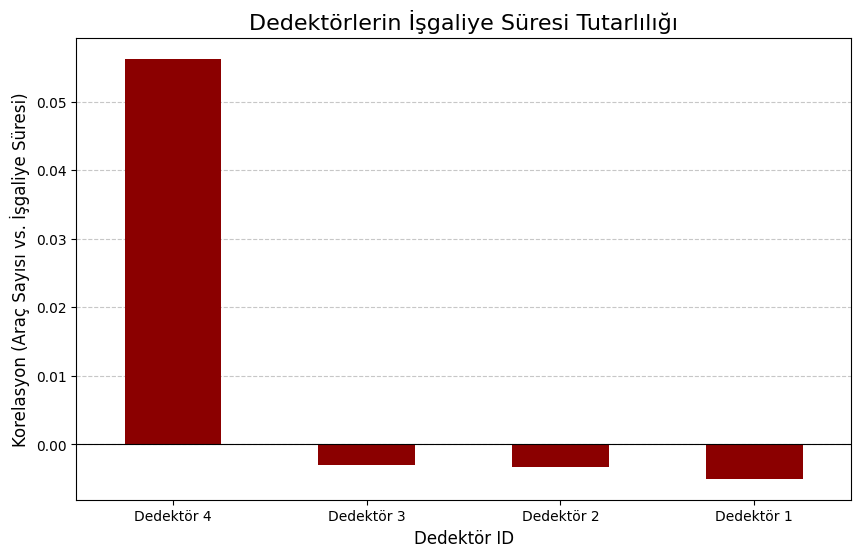


Sonuç: En tutarlı ölçümü yapan dedektör, 0.056 korelasyon puanı ile 'Dedektör 4' olarak bulunmuştur.
Bu dedektör, araç sayısı arttıkça işgaliye süresinin de en mantıklı şekilde arttığı şeridi temsil etmektedir.


In [55]:
# 'start_time' sütununun datetime formatında olduğundan emin olalım.
df['start_time'] = pd.to_datetime(df['start_time'])

# Analiz edilecek dedektör ID'lerini bir listede tutalım
dedektor_idler = sorted(df['detector_id'].unique())

# Her dedektörün korelasyon sonucunu saklamak için boş bir sözlük oluşturalım
korelasyon_sonuclari = {}


print("Her dedektör için tutarlılık analizi yapılıyor...")

for detector_id in dedektor_idler:
    # Veri setini sadece o anki dedektöre göre filtrele
    df_dedektor = df[df['detector_id'] == detector_id]
    
    # O dedektör için 'total' ve 'occupancy_time' arasındaki korelasyonu hesapla
    korelasyon = df_dedektor[['total', 'occupancy_time']].corr()
    
    # Matristen sadece bizi ilgilendiren korelasyon değerini al (total vs occupancy_time)
    korelasyon_degeri = korelasyon.iloc[0, 1]
    
    # Sonucu sözlüğe ekle
    korelasyon_sonuclari[f'Dedektör {detector_id}'] = korelasyon_degeri
    print(f"- Dedektör {detector_id} için korelasyon hesaplandı: {korelasyon_degeri:.3f}")



# Sonuçları daha kolay işlemek için bir pandas Serisine dönüştürelim
sonuclar_serisi = pd.Series(korelasyon_sonuclari).sort_values(ascending=False)

print("\n--- ANALİZ SONUCU ---")
print("Dedektörlerin Tutarlılık (Korelasyon) Puanları:")
print(sonuclar_serisi.round(3))

# Sonucu bir sütun grafiği ile görselleştirelim
plt.figure(figsize=(10, 6))
sonuclar_serisi.plot(kind='bar', color='darkred', zorder=2)
plt.title('Dedektörlerin İşgaliye Süresi Tutarlılığı', fontsize=16)
plt.xlabel('Dedektör ID', fontsize=12)
plt.ylabel('Korelasyon (Araç Sayısı vs. İşgaliye Süresi)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.8) # Sıfır çizgisini ekle
plt.show()


en_tutarli_dedektor = sonuclar_serisi.idxmax()
en_tutarli_deger = sonuclar_serisi.max()

print(f"\nSonuç: En tutarlı ölçümü yapan dedektör, {en_tutarli_deger:.3f} korelasyon puanı ile '{en_tutarli_dedektor}' olarak bulunmuştur.")
print("Bu dedektör, araç sayısı arttıkça işgaliye süresinin de en mantıklı şekilde arttığı şeridi temsil etmektedir.")



4.DEDEKTÖR İŞGALİYE SÜRESİ - YAĞIŞ KORELASYONU

Hava durumu verisi hazırlanıyor...
Sadece Dedektör 4'e ait trafik verisi hazırlanıyor...
Günlük yağış ve Dedektör 4 işgaliye verileri birleştiriliyor...

Analiz sonuçları oluşturuluyor...


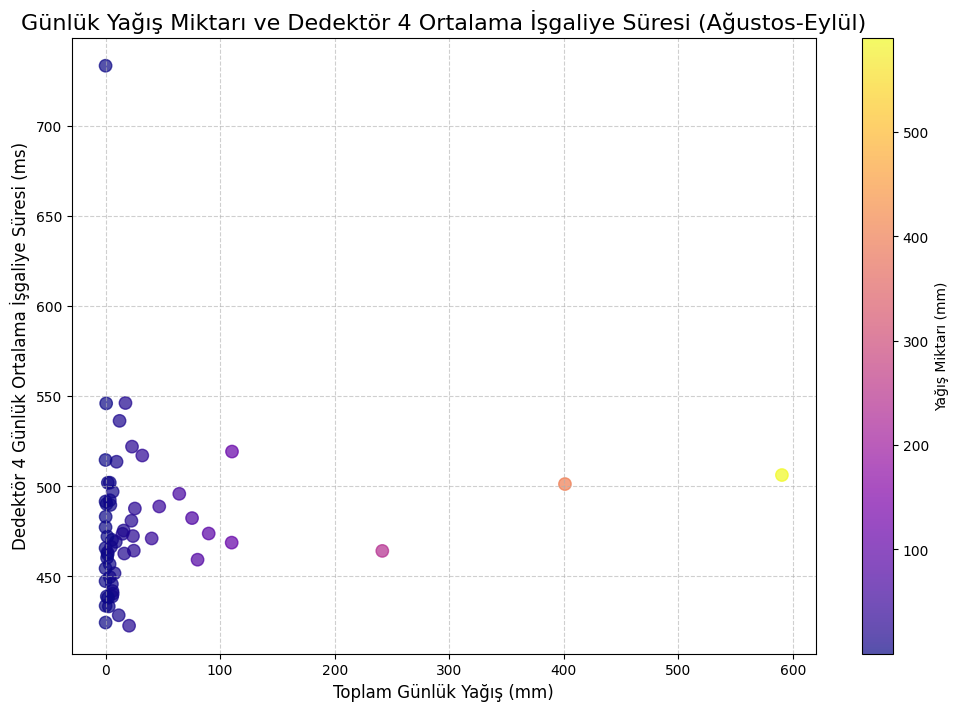


Yağış ve Dedektör 4 İşgaliye Süresi Arasındaki Korelasyon:
                  precipitation_mm  occupancy_time
precipitation_mm          1.000000        0.095809
occupancy_time            0.095809        1.000000


In [56]:
print("Hava durumu verisi hazırlanıyor...")
dosya_listesi = ['data_0.nc', 'data_0.nc 2', 'data_0.nc 3', 'data_0.nc 4']
tum_hava_verileri = []
for dosya_adi in dosya_listesi:
    try:
        hava_dataseti = xr.open_dataset(dosya_adi, engine='netcdf4')
        df_hava = hava_dataseti.to_dataframe().reset_index()
        if 'valid_time' in df_hava.columns:
            df_hava = df_hava.rename(columns={'valid_time': 'saatlik_zaman'})
        elif 'time' in df_hava.columns:
            df_hava = df_hava.rename(columns={'time': 'saatlik_zaman'})
        tum_hava_verileri.append(df_hava[['saatlik_zaman', 'tp']])
    except Exception as e:
        print(f"'{dosya_adi}' okunurken bir hata oluştu: {e}")

if tum_hava_verileri:
    birlesik_hava_df = pd.concat(tum_hava_verileri, ignore_index=True)
    birlesik_hava_df['precipitation_mm'] = birlesik_hava_df['tp'] * 1000
    birlesik_hava_df['saatlik_zaman'] = pd.to_datetime(birlesik_hava_df['saatlik_zaman'])
    birlesik_hava_df = birlesik_hava_df.set_index('saatlik_zaman')
    
    # Günlük toplam yağış miktarını hesapla
    gunluk_yagislar = birlesik_hava_df['precipitation_mm'].resample('D').sum()
    gunluk_yagislar.index.name = 'gun'

print("Sadece Dedektör 4'e ait trafik verisi hazırlanıyor...")
# 'start_time' sütununun datetime olduğundan emin olalım
df['start_time'] = pd.to_datetime(df['start_time'])

df_dedektor_4 = df[df['detector_id'] == 4].copy()

# Her kaydın gününü belirten yeni bir sütun oluştur
df_dedektor_4['gun'] = pd.to_datetime(df_dedektor_4['start_time'].dt.date)

# Sadece Dedektör 4 için günlük ortalama işgaliye süresini hesapla
gunluk_isgaliye_d4 = df_dedektor_4.groupby('gun')['occupancy_time'].mean()


print("Günlük yağış ve Dedektör 4 işgaliye verileri birleştiriliyor...")
karsilastirma_d4_df = pd.merge(
    gunluk_yagislar.reset_index(),
    gunluk_isgaliye_d4.reset_index(),
    on='gun'
)
# Sadece Ağustos ve Eylül aylarını filtrele
karsilastirma_d4_df = karsilastirma_d4_df[karsilastirma_d4_df['gun'].dt.month.isin([8, 9])]


print("\nAnaliz sonuçları oluşturuluyor...")
plt.figure(figsize=(12, 8))
plt.scatter(
    karsilastirma_d4_df['precipitation_mm'],
    karsilastirma_d4_df['occupancy_time'],
    alpha=0.7,
    s=80,
    c=karsilastirma_d4_df['precipitation_mm'],
    cmap='plasma'
)
plt.title('Günlük Yağış Miktarı ve Dedektör 4 Ortalama İşgaliye Süresi (Ağustos-Eylül)', fontsize=16)
plt.xlabel('Toplam Günlük Yağış (mm)', fontsize=12)
plt.ylabel('Dedektör 4 Günlük Ortalama İşgaliye Süresi (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.colorbar(label='Yağış Miktarı (mm)')
plt.show()

korelasyon_d4 = karsilastirma_d4_df[['precipitation_mm', 'occupancy_time']].corr()
print("\nYağış ve Dedektör 4 İşgaliye Süresi Arasındaki Korelasyon:")
print(korelasyon_d4)



pozitif çok zayıf korelasyon çıktı. evet belki pozitif beklediğimiz gibi doğru orantılı ancak ciddi derece zayıf olduğundan dolayı hiçbir şeyi kanıtlamaz